In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.models as models
import torchvision.transforms.functional as F2


csv_drive_path = "."
train_path = "./train"
test_path = "./test"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),          
    transforms.RandomResizedCrop(224),     
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(15),         
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

class ImageCSVDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, label_map=None, is_test=False):
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.label_map = label_map
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clean_filename = os.path.basename(row['path']) 
        img_path = os.path.join(self.root_dir, clean_filename)

        image = Image.open(img_path).convert('RGB')

        
        if self.transform:
            image = self.transform(image)

        if self.is_test:
            image_id = int(row['ID'])
            return image, image_id
        else:
            label = self.label_map[row['target']]
            character = row['character']
            return image, label, character


label_map = {"bad": 0, "good": 1}

train_dataset = ImageCSVDataset(
    csv_file=os.path.join(csv_drive_path, "train.csv"), 
    root_dir=train_path,    
    transform=None, 
    label_map=label_map
)

print(f"train_dataset successfully initialized with {len(train_dataset)} images.")

train_dataset successfully initialized with 1245 images.


--- Class Distribution ---
target
good    894
bad     351
Name: count, dtype: int64


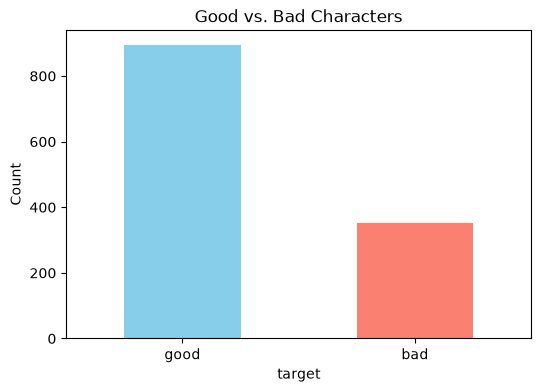


--- Sample Images ---


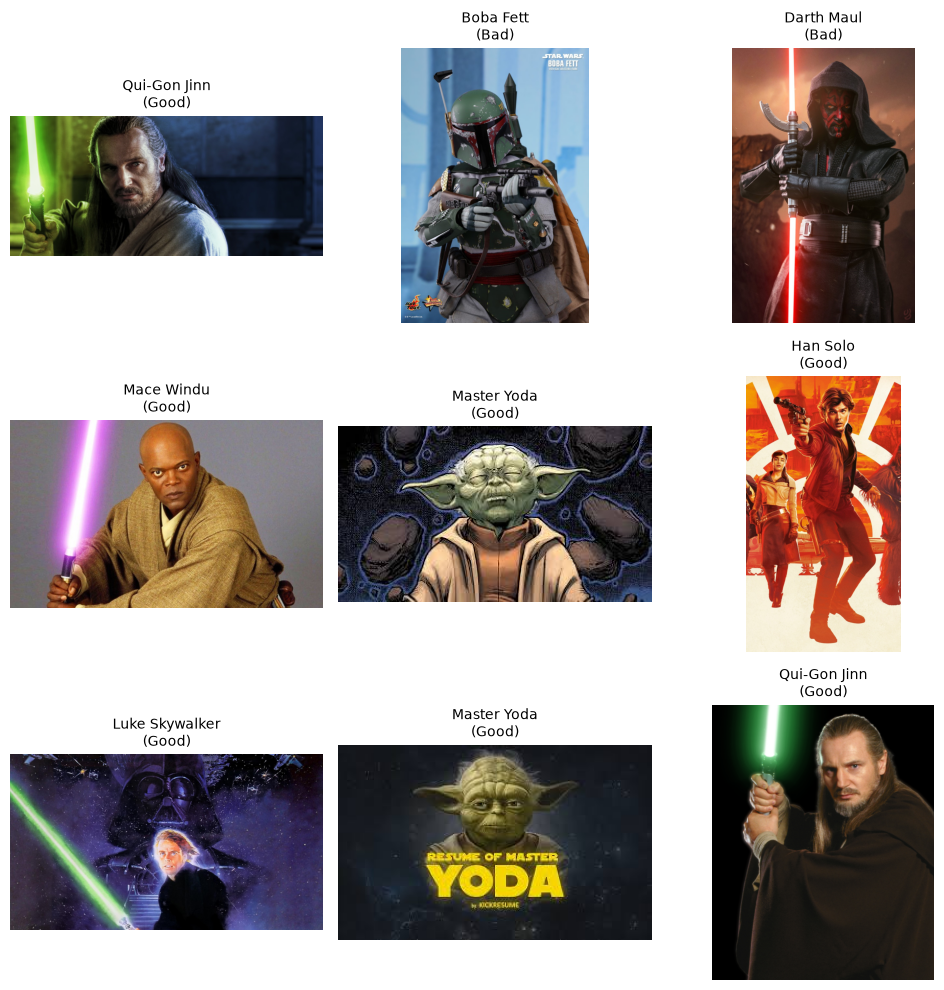

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image


print("--- Class Distribution ---")

class_counts = train_dataset.df['target'].value_counts()
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Good vs. Bad Characters')
plt.ylabel('Count')
plt.xticks(rotation=0) 
plt.show()


print("\n--- Sample Images ---")
plt.figure(figsize=(10, 10))


sample_df = train_dataset.df.sample(9)

for i, (_, row) in enumerate(sample_df.iterrows()):
    clean_filename = os.path.basename(row['path']) 
    
   
    candidate_paths = [
        os.path.join(train_path, clean_filename),          
        os.path.join(train_path, 'train', clean_filename),
        row['path'],                                       
        os.path.join('.', row['path'])                     
    ]
    
    img_path = None
    for candidate in candidate_paths:
        if os.path.exists(candidate):
            img_path = candidate
            break
            
    if img_path is None:
        raise FileNotFoundError(
            f"\nCould not find '{clean_filename}' anywhere!\n"
            f"Looked in: {candidate_paths}\n"
            f"Please verify that your 'train' folder contains actual .jpg images."
        )
  
    img = Image.open(img_path)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    
   
    label_name = row['target'].capitalize()
    plt.title(f"{row['character']}\n({label_name})", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

MODEL_NAME = "efficientnet_b0"  
LEARNING_RATE = 3e-4           
BATCH_SIZE = 32
EPOCHS = 2
FINE_TUNE = True                


class StarWarsClassifier(nn.Module):
    def __init__(self, model_name="efficientnet_b0", num_classes=2, fine_tune=True):
        super(StarWarsClassifier, self).__init__()
        print(f"Building model architecture using: {model_name}...")
        
        if model_name == "efficientnet_b0":
            self.model = models.efficientnet_b0(weights='DEFAULT')
           
            for param in self.model.parameters():
                param.requires_grad = fine_tune
            
            
            in_features = self.model.classifier[1].in_features
            self.model.classifier[1] = nn.Linear(in_features, num_classes)
            
        elif model_name == "convnext_tiny":
            self.model = models.convnext_tiny(weights='DEFAULT')
            for param in self.model.parameters():
                param.requires_grad = fine_tune
                
           
            in_features = self.model.classifier[2].in_features
            self.model.classifier[2] = nn.Linear(in_features, num_classes)
            
        elif model_name == "resnet50":
            self.model = models.resnet50(weights='DEFAULT')
            for param in self.model.parameters():
                param.requires_grad = fine_tune
                
            
            in_features = self.model.fc.in_features
            self.model.fc = nn.Linear(in_features, num_classes)
        else:
            raise ValueError(f"Unknown model architecture: {model_name}")
        
    def forward(self, x):
        return self.model(x)


model = StarWarsClassifier(model_name=MODEL_NAME, num_classes=2, fine_tune=FINE_TUNE).to(device)
criterion = nn.CrossEntropyLoss()


optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=1e-4)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print("Model, Optimizer (AdamW), and Scheduler initialized successfully!")

🏗️ Building model architecture using: efficientnet_b0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


✅ Model, Optimizer (AdamW), and Scheduler initialized successfully!


In [ ]:
import os
import copy
import torch
from torch.utils.data import random_split, DataLoader


if hasattr(train_dataset, 'root_dir') and hasattr(train_dataset, 'df'):
    
    sample_filename = os.path.basename(train_dataset.df.iloc[0]['path'])
    
    
    candidates = [
        train_dataset.root_dir,
        os.path.join(train_dataset.root_dir, 'train'),
        os.path.join(train_dataset.root_dir, 'train', 'train'),
        '.',
        './train',
        './train/train'
    ]
    
    for cand in candidates:
        if os.path.exists(os.path.join(cand, sample_filename)):
            train_dataset.root_dir = cand
            break
    print(f"Smart Path Resolver: Verified image directory path -> '{train_dataset.root_dir}'")


train_size = int(0.7 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))
test_size = len(train_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(train_dataset, [train_size, val_size, test_size])


train_subset.dataset = copy.copy(train_dataset)
train_subset.dataset.transform = train_transform

val_subset.dataset = copy.copy(train_dataset)
val_subset.dataset.transform = val_transform

test_subset.dataset = copy.copy(train_dataset)
test_subset.dataset.transform = val_transform


train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
local_test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

def train_one_epoch(model, dataloader):
    model.train()
    total_loss = 0

    for batch in dataloader:
        imgs, labels, _ = batch
        imgs, labels = imgs.to(device), labels.to(device)

        
        optimizer.zero_grad()           
        outputs = model(imgs)           
        loss = criterion(outputs, labels) 
        loss.backward()                 
        optimizer.step()                
        
        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for batch in dataloader:
            imgs, labels, _ = batch
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    return correct / total


print("Starting Training...")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)
    test_acc = evaluate(model, local_test_loader)
    
    
    scheduler.step(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: Loss = {train_loss:.4f} | Val Acc = {val_acc:.2%} | Test Acc = {test_acc:.2%}")

🔄 Smart Path Resolver: Verified image directory path -> './train\train'
Starting Training...
Epoch 1/2: Loss = 0.3552 | Val Acc = 90.86% | Test Acc = 89.89%
Epoch 2/2: Loss = 0.1629 | Val Acc = 95.16% | Test Acc = 93.09%


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader


test_dataset = ImageCSVDataset(
    csv_file=os.path.join(csv_drive_path, "test.csv"), 
    root_dir=test_path,    
    transform=val_transform,
    is_test=True
)


if hasattr(test_dataset, 'root_dir') and hasattr(test_dataset, 'df'):
    sample_filename = os.path.basename(test_dataset.df.iloc[0]['path'])
    
    candidates = [
        test_dataset.root_dir,
        os.path.join(test_dataset.root_dir, 'test'),
        os.path.join(test_dataset.root_dir, 'test', 'test'),
        '.',
        './test',
        './test/test'
    ]
    
    for cand in candidates:
        if os.path.exists(os.path.join(cand, sample_filename)):
            test_dataset.root_dir = cand
            break
    print(f"Smart Path Resolver: Verified test image directory path -> '{test_dataset.root_dir}'")

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

idx2label = {v: k for k, v in label_map.items()}

model.eval()
preds = []
ids = []

print("starting final inference...")
with torch.no_grad():
    for image, image_id in test_loader:
        image = image.to(device)
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)
        
        preds.extend(predicted.cpu().numpy())
        ids.extend([id.item() if isinstance(id, torch.Tensor) else id for id in image_id])


pred_labels = [idx2label[p] for p in preds]
submission = pd.DataFrame({
    "ID": ids,
    "target": pred_labels
})


submission = submission.sort_values("ID")


output_file = "submission.csv" 
submission.to_csv(output_file, index=False)


if os.path.exists(output_file):
    print(f"success: '{output_file}' created locally with {len(submission)} rows.")
    
    print(submission.head())
else:
    print("error: submission file was not saved!")

🔄 Smart Path Resolver: Verified test image directory path -> './test\test'
starting final inference...
✅ success: 'submission.csv' created locally with 300 rows.
   ID target
0   0   good
1   1   good
2   2   good
3   3   good
4   4   good


In [20]:
torch.save(model.state_dict(), "starwars_model.pth")